In [14]:
# -*- coding: utf-8 -*-
# Anomaly_Detection_on_Graphs / notebooks / 01_data_exploration.ipynb
# Purpose: 載入Elliptic數據集，檢查結構、統計資訊、類別分布

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# =====================================
# 1. 設定路徑（根據你的實際位置調整）
# =====================================
DATA_ROOT = "/content/drive/MyDrive/data/raw/"

CLASSES_PATH = DATA_ROOT + "elliptic_txs_classes.csv"
EDGES_PATH   = DATA_ROOT + "elliptic_txs_edgelist.csv"
FEATS_PATH   = DATA_ROOT + "elliptic_txs_features.csv"

# 檢查檔案是否存在
import os
for path in [CLASSES_PATH, EDGES_PATH, FEATS_PATH]:
    if os.path.exists(path):
        print(f"找到檔案: {path}")
    else:
        print(f"找不到: {path} → 請確認上傳成功")


找到檔案: /content/drive/MyDrive/data/raw/elliptic_txs_classes.csv
找到檔案: /content/drive/MyDrive/data/raw/elliptic_txs_edgelist.csv
找到檔案: /content/drive/MyDrive/data/raw/elliptic_txs_features.csv


In [16]:
# 正式載入
df_classes = pd.read_csv(CLASSES_PATH)
df_edges   = pd.read_csv(EDGES_PATH)
df_feats   = pd.read_csv(FEATS_PATH, header=None)

print("載入成功！Classes 前5行：")
print(df_classes.head())

載入成功！Classes 前5行：
        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown


In [24]:
# 重新命名特徵欄位
df_feats.columns = ['txId'] + [f'feat_{i}' for i in range(1, 167)]     # hardcode 166特徵 + txId

print("=== Classes 概覽 ===")
print(df_classes.head())                    # returns the first five rows
print("\n")
print(df_classes['class'].value_counts())   # 看 '1','2','unknown' 分布
print(df_classes.shape)

print("\n=== Edges 概覽 ===")
print(df_edges.head())
print("\n")
print(f"總邊數: {len(df_edges)}")
print(df_edges.shape)

print("\n=== Features 概覽 ===")
print(df_feats.head())
print(f"特徵維度: {df_feats.shape[1]-1}")  # 應為166
print(df_feats.shape)

=== Classes 概覽 ===
        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown


class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
(203769, 2)

=== Edges 概覽 ===
       txId1      txId2
0  230425980    5530458
1  232022460  232438397
2  230460314  230459870
3  230333930  230595899
4  232013274  232029206


總邊數: 234355
(234355, 2)

=== Features 概覽 ===
        txId  feat_1    feat_2    feat_3    feat_4     feat_5    feat_6  \
0  230425980       1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458       1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460       1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397       1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314       1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

     feat_7     feat_8    feat_9  ...  feat_157  feat_158  feat_159  feat_160  \
0 -0.113

In [30]:
# =====================================
# 3. 過濾有標記數據 & 映射標籤
# =====================================
df_classes = df_classes[df_classes['class'] != 'unknown']        # 只保留 '1' 和 '2' 的行  
df_classes['label'] = df_classes['class'].map({'1': 1, '2': 0})  # 1=異常(illicit), 0=正常, change '1','2' to 1,0

print("\n標記數據分布（二元）：")
print(df_classes['label'].value_counts(normalize=True))  # 顯示不平衡程度

# 最終檢查
print("\n=== 最終 Classes 概覽 ===")
print(df_classes.head())
print(df_classes.shape)


標記數據分布（二元）：
label
0    0.902392
1    0.097608
Name: proportion, dtype: float64

=== 最終 Classes 概覽 ===
         txId class  label
3   232438397     2      0
9   232029206     2      0
10  232344069     2      0
11   27553029     2      0
16    3881097     2      0
(46564, 3)



圖基本統計：
節點數: 203769
邊數: 234355
是否連通: False


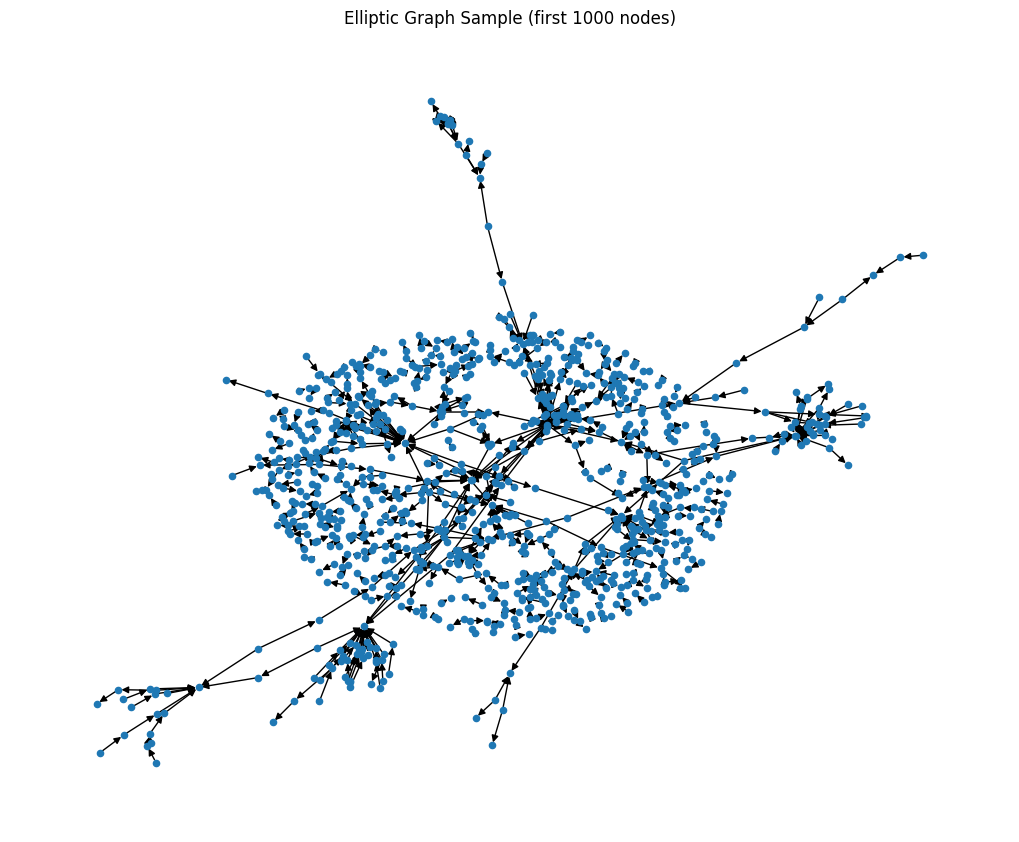

In [ ]:
# =====================================
# 4. 建構圖（NetworkX）
# =====================================
# create networkx graph from pandas edge list dataframe
G = nx.from_pandas_edgelist(df_edges, 'txId1', 'txId2', create_using=nx.DiGraph())         # creating an edge (txId1 -> txId2), nx.DiGraph() specifies that G should be a directed graph (DiGraph)

print(f"\n圖基本統計：")
print(f"節點數: {G.number_of_nodes()}")
print(f"邊數: {G.number_of_edges()}")
print(f"是否連通: {nx.is_weakly_connected(G)}")  # 弱連通檢查 check if all the nodes are reachable from each other when ignoring edge directions

# 可視化小樣本（前1000節點，避免太大畫不出）
sub_G = G.subgraph(list(G.nodes())[:1000]) # 取前1000個節點的子圖
pos = nx.spring_layout(sub_G)  # spring layout for better visualization, connected nodes will be closer together, unconnected nodes will be farther apart
plt.figure(figsize=(10,8))      #   set figure size for 10inch horizontal and 8inch vertical
nx.draw(sub_G, pos, node_size=20, arrows=True)  # node_size=20, arrows=True shows the direction of edges
plt.title("Elliptic Graph Sample (first 1000 nodes)")
plt.show()

In [ ]:
# =====================================
# 5. 簡單結論（你可以寫在Markdown cell）
# =====================================
# - 數據高度不平衡（異常約2%）
# - 圖很大（~200k nodes, ~234k edges）
# - 有向圖，適合捕捉錢流方向

# The data is highly imbalanced (anomalies are about 2%).
# The graph is large (~200k nodes, ~234k edges).
# It's a directed graph, suitable for capturing the direction of money flow.